<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <img src="../assets/branding/logoUgrupo.png" alt="Universidad del Magdalena y GIDSYC" style="height: 76px; max-width: 34%; object-fit: contain;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Modelos de difusión para IA generativa</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 04</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Modelo DDPM no condicional para predicción de ruido</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Semillero GIDSYC | Facultad de Ingenierías | Programa de Ingeniería de Sistemas</div>
    </div>
    <img src="../assets/branding/logo_semillero.png" alt="Semillero GIDSYC" style="height: 74px; object-fit: contain;">
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
  <div><strong>Grupo:</strong> GIDSYC</div>
  <div><strong>Unidad:</strong> Semillero GIDSYC</div>
  <div><strong>Universidad:</strong> Universidad del Magdalena</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Pregunta directriz

> ¿Cómo representamos la función $\epsilon_\theta(x_t,t)$ con una red neuronal entrenable y suficientemente expresiva?

Los notebooks anteriores construyeron la formulación: datos, ruido gaussiano, proceso directo y objetivo de predicción de ruido. En este notebook damos el primer paso entrenable. Reemplazamos la función abstracta $\epsilon_\theta$ por una red convolucional compacta condicionada por tiempo.

El objetivo no es construir una arquitectura industrial. El objetivo es mostrar que la técnica funciona: podemos entrenar una función que recibe una imagen ruidosa $x_t$, recibe el tiempo $t$ y aprende a predecir el ruido $\epsilon$ usado para corromper la muestra. Esa predicción, insertada en una cadena reverse, ya permite generar dibujos desde ruido gaussiano.


## Objetivos

Al finalizar este notebook, el estudiante debería estar en capacidad de:

1. Construir mini-lotes dinámicos de entrenamiento para predicción de ruido.
2. Implementar una codificación sinusoidal simple del tiempo $t$.
3. Definir una arquitectura convolucional multiescala para representar $\epsilon_\theta(x_t,t)$.
4. Entrenar el modelo con pérdida cuadrática sobre ruido.
5. Evaluar denoising mediante reconstrucción de $\hat{x}_0$.
6. Ejecutar un primer muestreo reverse básico desde ruido gaussiano.
7. Distinguir entre aprender a predecir ruido y usar esa predicción para generar muestras.


## Marco conceptual

El notebook 03 estableció que el entrenamiento DDPM básico puede formularse como

$$
\mathcal{L}(\theta)
=
\mathbb{E}_{x_0,t,\epsilon}
\left[
\left\|
\epsilon-\epsilon_\theta(x_t,t)
\right\|_2^2
\right].
$$

Ahora debemos escoger una familia de funciones para representar $\epsilon_\theta$. Una CNN plana puede aprender parte del denoising local, pero suele tener dificultades para producir estructura global durante el muestreo: en una casa, el techo, las paredes y la puerta deben aparecer con relaciones espaciales coherentes. Por eso usamos una U-Net mínima, no una arquitectura industrial: solo dos reducciones de resolución, dos expansiones y conexiones laterales.

La decisión conserva la claridad conceptual. El modelo sigue siendo una función $\epsilon_\theta(x_t,t)$; simplemente le damos suficiente contexto espacial para que el primer muestreo generativo sea reconocible. La red no es un generador autónomo en el sentido tradicional. Es un estimador de ruido que se vuelve generativo cuando se usa dentro de la cadena reverse.


## Formulación matemática

Durante entrenamiento, para cada muestra limpia $x_0$ construimos

$$
x_t
=
\sqrt{\bar{\alpha}_t}\,x_0
+
\sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,I).
$$

La red recibe $(x_t,t)$ y produce

$$
\epsilon_\theta(x_t,t).
$$

La pérdida de un mini-lote de tamaño $B$ será

$$
\widehat{\mathcal{L}}(\theta)
=
\frac{1}{B}
\sum_{i=1}^{B}
\left\|
\epsilon^{(i)}
-
\epsilon_\theta(x_{t_i}^{(i)},t_i)
\right\|_2^2.
$$

Para muestrear, usaremos una forma reverse DDPM básica. Dado $x_t$ y una predicción de ruido, se define una media aproximada

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
 x_t
 -
 \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}
 \epsilon_\theta(x_t,t)
\right).
$$

Luego se toma un paso hacia $x_{t-1}$. En este notebook lo usaremos solo como prueba funcional; el análisis serio del muestreo queda para el notebook 05.


## Preparación del entorno


In [1]:
from pathlib import Path
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_PATH = ROOT / "data" / "quickdraw" / "processed" / "quickdraw_house_50k_28x28.npz"

SEED = 20260419
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(DEVICE))
else:
    print("Advertencia: no se detectó GPU. El entrenamiento puede tardar bastante más en CPU.")

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["image.cmap"] = "gray_r"


PyTorch: 2.8.0+cu126
Dispositivo: cuda:0
GPU: NVIDIA RTX A6000


## Dataset y mini-lotes dinámicos

Usaremos la categoría `house` de QuickDraw, normalizada a $[-1,1]$. El dataset que entra al `DataLoader` contiene solo muestras limpias $x_0$. Los tiempos $t$, los ruidos $\epsilon$ y las entradas ruidosas $x_t$ se generan dentro del ciclo de entrenamiento.

Este diseño evita almacenar todas las versiones ruidosas. En cada época, el modelo ve nuevas corrupciones del mismo conjunto de imágenes.


In [2]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATASET_PATH}. "
        "Verifica que esta distribucion incluya data/quickdraw/processed/quickdraw_house_50k_28x28.npz"
    )

with np.load(DATASET_PATH) as data:
    x_train_uint8 = data["x_train"]
    class_names = data["class_names"]

MAX_TRAIN_SAMPLES = 20_000
BATCH_SIZE = 256

x_01 = x_train_uint8[:MAX_TRAIN_SAMPLES].astype(np.float32) / 255.0
x_train = 2.0 * x_01 - 1.0
x_train_tensor = torch.from_numpy(x_train[:, None, :, :])

loader = DataLoader(
    TensorDataset(x_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
)

print(f"Clase: {class_names[0]}")
print(f"Muestras usadas: {len(x_train_tensor)}")
print(f"Forma tensorial: {tuple(x_train_tensor.shape)}")
print(f"Mini-lotes por época: {len(loader)}")

Clase: house
Muestras usadas: 20000
Forma tensorial: (20000, 1, 28, 28)
Mini-lotes por época: 78


## Agenda de ruido

Mantendremos la misma agenda lineal usada en notebooks anteriores. Esta decisión permite comparar visualmente el entrenamiento con la difusión directa ya estudiada.


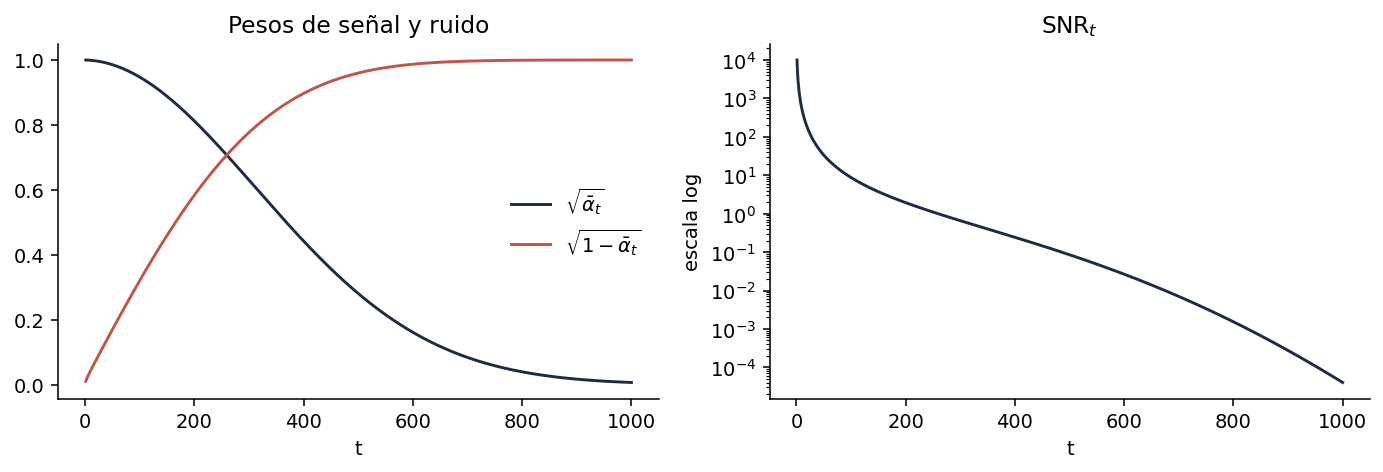

In [3]:
T = 1000
beta_inicio = 1e-4
beta_fin = 2e-2

betas = torch.linspace(beta_inicio, beta_fin, T, dtype=torch.float32, device=DEVICE)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
timesteps = torch.arange(1, T + 1, device=DEVICE)


def q_sample(x0, t_index, eps=None):
    if eps is None:
        eps = torch.randn_like(x0)
    alpha_bar_t = alpha_bars[t_index].view(-1, 1, 1, 1)
    xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1.0 - alpha_bar_t) * eps
    return xt, eps

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(timesteps.cpu(), torch.sqrt(alpha_bars).cpu(), label=r"$\sqrt{\bar{\alpha}_t}$", color="#1f2a44")
axes[0].plot(timesteps.cpu(), torch.sqrt(1 - alpha_bars).cpu(), label=r"$\sqrt{1-\bar{\alpha}_t}$", color="#c05746")
axes[0].set_title("Pesos de señal y ruido")
axes[0].set_xlabel("t")
axes[0].legend(frameon=False)

snr = alpha_bars / torch.clamp(1 - alpha_bars, min=1e-12)
axes[1].plot(timesteps.cpu(), snr.cpu(), color="#1f2a44")
axes[1].set_yscale("log")
axes[1].set_title(r"$\mathrm{SNR}_t$")
axes[1].set_xlabel("t")
axes[1].set_ylabel("escala log")
fig.tight_layout()

## Codificación temporal

La red debe saber en qué tiempo de difusión está trabajando. Usaremos una codificación sinusoidal, similar en espíritu a las codificaciones posicionales usadas en modelos modernos. La entrada será el índice $t$ y la salida será un vector de dimensión fija.

Esta codificación no se aprende directamente; lo que se aprende es cómo usarla dentro de la red.


Forma del embedding: (6, 64)


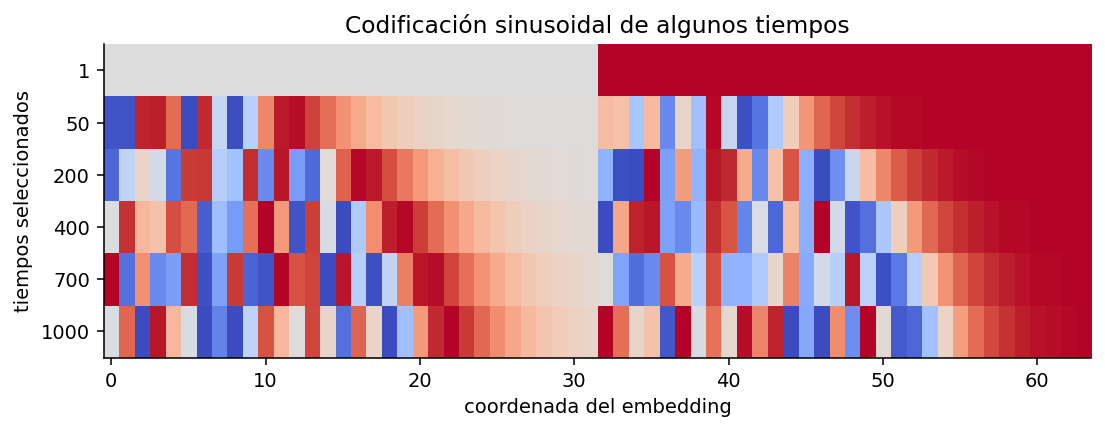

In [4]:
def sinusoidal_time_embedding(t, dim=64):
    """Return sinusoidal embeddings for integer timesteps t."""
    half = dim // 2
    t = t.float()
    freqs = torch.exp(
        -math.log(10000.0) * torch.arange(half, device=t.device) / max(half - 1, 1)
    )
    args = t[:, None] * freqs[None, :]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    return emb

sample_t = torch.tensor([0, 49, 199, 399, 699, 999], device=DEVICE)
emb = sinusoidal_time_embedding(sample_t, dim=64)
print("Forma del embedding:", tuple(emb.shape))

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.imshow(emb.detach().cpu().numpy(), aspect="auto", cmap="coolwarm")
ax.set_title("Codificación sinusoidal de algunos tiempos")
ax.set_xlabel("coordenada del embedding")
ax.set_ylabel("tiempos seleccionados")
ax.set_yticks(range(len(sample_t)))
ax.set_yticklabels([str(int(t.item()) + 1) for t in sample_t])
fig.tight_layout()

## Arquitectura multiescala condicionada por tiempo

Una CNN completamente local puede aprender a quitar ruido, pero suele fallar al generar estructura global: una casa requiere techo, paredes y trazos coherentes en posiciones relativas. Por eso usamos una arquitectura multiescala mínima: reduce la resolución espacial, procesa una representación más compacta y luego recupera la resolución original con conexiones laterales.

La operación sigue siendo la misma desde el punto de vista matemático. El modelo recibe $x_t$ y $t$, y devuelve una predicción de ruido $\epsilon_\theta(x_t,t)$. La parte multiescala no cambia el objetivo DDPM; solo mejora la capacidad de la red para coordinar información local y global.


In [5]:
class TimeConditionedBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_channels)
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        time_bias = self.time_proj(t_emb)[:, :, None, None]
        h = self.act(self.conv1(x) + time_bias)
        h = self.conv2(h)
        return self.act(h + self.skip(x))


class TinyTimeUNet(nn.Module):
    def __init__(self, time_dim=64, base=48):
        super().__init__()
        self.time_dim = time_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.input_block = TimeConditionedBlock(1, base, time_dim)
        self.down1 = nn.Conv2d(base, 2 * base, kernel_size=4, stride=2, padding=1)
        self.encoder_block = TimeConditionedBlock(2 * base, 2 * base, time_dim)
        self.down2 = nn.Conv2d(2 * base, 2 * base, kernel_size=4, stride=2, padding=1)
        self.middle_block = TimeConditionedBlock(2 * base, 2 * base, time_dim)

        self.up1 = nn.ConvTranspose2d(2 * base, 2 * base, kernel_size=4, stride=2, padding=1)
        self.decoder_block = TimeConditionedBlock(4 * base, base, time_dim)
        self.up2 = nn.ConvTranspose2d(base, base, kernel_size=4, stride=2, padding=1)
        self.output_block = TimeConditionedBlock(2 * base, base, time_dim)
        self.output_conv = nn.Conv2d(base, 1, kernel_size=3, padding=1)

    def forward(self, x, t_index):
        t_emb = sinusoidal_time_embedding(t_index, dim=self.time_dim)
        t_emb = self.time_mlp(t_emb)

        skip_28 = self.input_block(x, t_emb)
        h_14 = self.encoder_block(self.down1(skip_28), t_emb)
        h_7 = self.middle_block(self.down2(h_14), t_emb)

        h = self.up1(h_7)
        h = self.decoder_block(torch.cat([h, h_14], dim=1), t_emb)
        h = self.up2(h)
        h = self.output_block(torch.cat([h, skip_28], dim=1), t_emb)
        return self.output_conv(h)


model = TinyTimeUNet(time_dim=64, base=48).to(DEVICE)
num_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Parámetros entrenables: {num_params:,}")


TinyTimeUNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (input_block): TimeConditionedBlock(
    (conv1): Conv2d(1, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Linear(in_features=64, out_features=48, bias=True)
    (skip): Conv2d(1, 48, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU()
  )
  (down1): Conv2d(48, 96, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (encoder_block): TimeConditionedBlock(
    (conv1): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_proj): Linear(in_features=64, out_features=96, bias=True)
    (skip): Identity()
    (act): SiLU()
  )
  (down2): Conv2d(96, 96, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (midd

## Diagrama de la arquitectura

El diagrama resume la operación principal. La rama superior transforma la imagen ruidosa por escalas espaciales

$$
28\times 28 \rightarrow 14\times 14 \rightarrow 7\times 7 \rightarrow 14\times 14 \rightarrow 28\times 28.
$$

La rama temporal inyecta información de $t$ en los bloques convolucionales. Las conexiones laterales recuperan detalle fino de las escalas tempranas, mientras que la representación central captura relaciones espaciales más amplias.


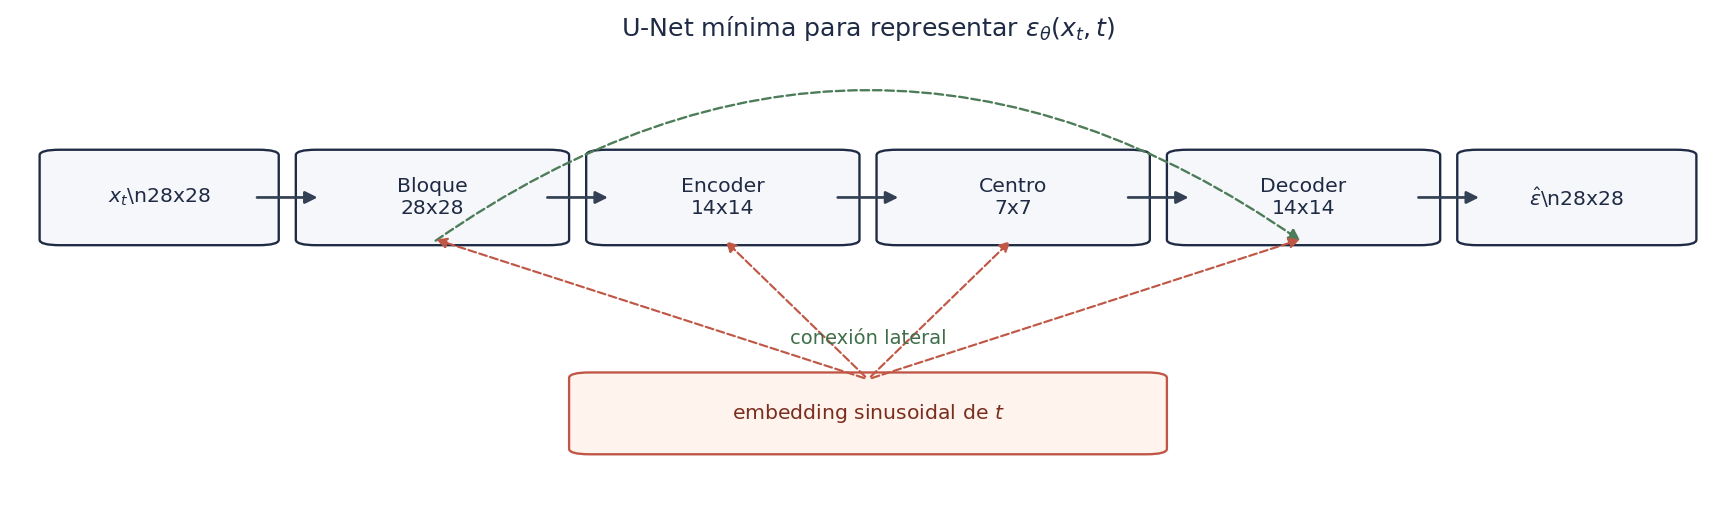

In [6]:
def draw_architecture_diagram():
    fig, ax = plt.subplots(figsize=(12.5, 3.8))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    boxes = [
        (0.03, 0.58, 0.11, 0.18, r"$x_t$\n28x28"),
        (0.18, 0.58, 0.13, 0.18, "Bloque\n28x28"),
        (0.35, 0.58, 0.13, 0.18, "Encoder\n14x14"),
        (0.52, 0.58, 0.13, 0.18, "Centro\n7x7"),
        (0.69, 0.58, 0.13, 0.18, "Decoder\n14x14"),
        (0.86, 0.58, 0.11, 0.18, r"$\hat{\epsilon}$\n28x28"),
    ]
    for x, y, w, h, label in boxes:
        patch = FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.015,rounding_size=0.012",
            facecolor="#f5f7fa", edgecolor="#1f2a44", linewidth=1.2,
        )
        ax.add_patch(patch)
        ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=10.5, color="#1f2a44")

    for i in range(len(boxes) - 1):
        x, y, w, h, _ = boxes[i]
        x2, y2, _, _, _ = boxes[i + 1]
        ax.add_patch(FancyArrowPatch((x + w, y + h / 2), (x2, y2 + h / 2), arrowstyle="-|>", mutation_scale=13, linewidth=1.4, color="#344054"))

    # Conexiones laterales: preservan detalle local mientras la rama central captura contexto.
    ax.add_patch(FancyArrowPatch((0.245, 0.57), (0.755, 0.57), connectionstyle="arc3,rad=-0.35", arrowstyle="-|>", mutation_scale=12, linewidth=1.2, color="#4d7c59", linestyle="--"))
    ax.text(0.50, 0.36, "conexión lateral", ha="center", va="center", fontsize=10, color="#3f6f4a")

    t_box = FancyBboxPatch((0.34, 0.12), 0.32, 0.15, boxstyle="round,pad=0.015,rounding_size=0.012", facecolor="#fff4ed", edgecolor="#c05746", linewidth=1.2)
    ax.add_patch(t_box)
    ax.text(0.50, 0.195, r"embedding sinusoidal de $t$", ha="center", va="center", fontsize=10.5, color="#7a2e1f")
    for x_target in [0.245, 0.415, 0.585, 0.755]:
        ax.add_patch(FancyArrowPatch((0.50, 0.27), (x_target, 0.58), arrowstyle="-|>", mutation_scale=11, linewidth=1.1, color="#c05746", linestyle="--"))

    ax.set_title(r"U-Net mínima para representar $\epsilon_\theta(x_t,t)$", fontsize=13, color="#1f2a44")
    fig.tight_layout()
    return fig

fig = draw_architecture_diagram()


## Entrenamiento

El entrenamiento genera un tiempo aleatorio y ruido nuevo para cada imagen del mini-lote. La red predice el ruido y se optimiza con MSE. Usamos una cantidad moderada de épocas porque este notebook debe mostrar generación real, no solo una pérdida decreciente.

En la GPU disponible durante el diseño del curso, esta configuración tarda cerca de 100 segundos. En CPU puede tardar bastante más; si no hay GPU, conviene reducir temporalmente `EPOCHS` solo para verificar el flujo, pero las muestras finales serán menos convincentes.

**Nota de ejecución.** Esta celda depende de las secciones anteriores: dataset, agenda de ruido, codificación temporal y arquitectura. Si se reinicia el kernel, conviene ejecutar el notebook desde el inicio antes de entrenar.


época 01/50 | loss promedio=0.5369 | loss final=0.2114
época 02/50 | loss promedio=0.2183 | loss final=0.2008
época 03/50 | loss promedio=0.1998 | loss final=0.1613
época 04/50 | loss promedio=0.1813 | loss final=0.1886
época 05/50 | loss promedio=0.1521 | loss final=0.1245
época 06/50 | loss promedio=0.1348 | loss final=0.1209
época 07/50 | loss promedio=0.1163 | loss final=0.1092
época 08/50 | loss promedio=0.1072 | loss final=0.1031
época 09/50 | loss promedio=0.0976 | loss final=0.0993
época 10/50 | loss promedio=0.0904 | loss final=0.1039
época 11/50 | loss promedio=0.0868 | loss final=0.0935
época 12/50 | loss promedio=0.0860 | loss final=0.0863
época 13/50 | loss promedio=0.0798 | loss final=0.0866
época 14/50 | loss promedio=0.0757 | loss final=0.0797
época 15/50 | loss promedio=0.0754 | loss final=0.0629
época 16/50 | loss promedio=0.0739 | loss final=0.0763
época 17/50 | loss promedio=0.0708 | loss final=0.0742
época 18/50 | loss promedio=0.0698 | loss final=0.0581
época 19/5

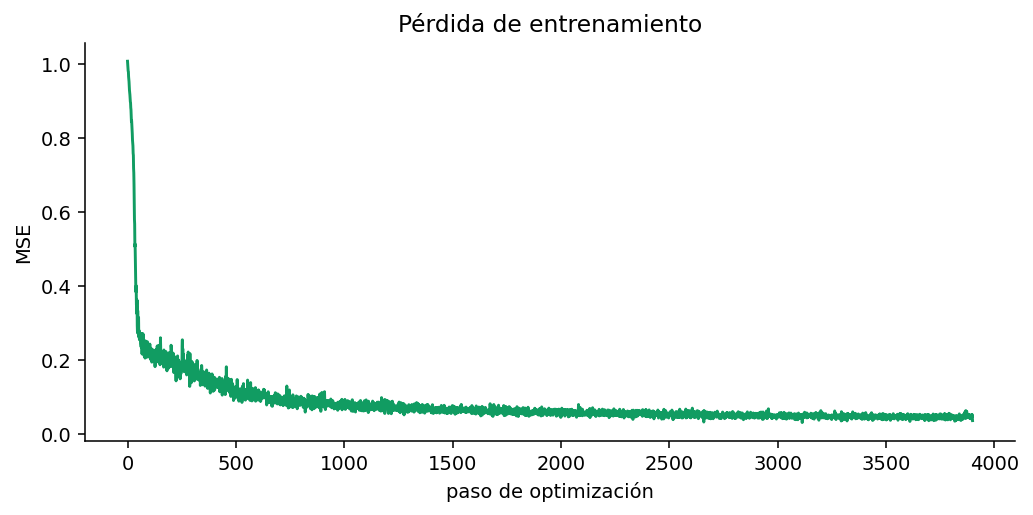

In [7]:
required_names = ["loader", "model", "q_sample", "alpha_bars", "DEVICE", "T"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Faltan variables requeridas: " + ", ".join(missing) +
        ". Ejecuta las celdas anteriores en orden desde 'Preparación del entorno'."
    )

LEARNING_RATE = 1e-4
EPOCHS = 50

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
loss_history = []
start_time = time.perf_counter()

model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_losses = []
    for (x0,) in loader:
        x0 = x0.to(DEVICE)
        b = x0.shape[0]
        t_index = torch.randint(0, T, (b,), device=DEVICE)
        eps = torch.randn_like(x0)
        xt, eps = q_sample(x0, t_index, eps)

        eps_pred = model(xt, t_index)
        loss = torch.mean((eps - eps_pred) ** 2)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        value = float(loss.detach().cpu())
        loss_history.append(value)
        epoch_losses.append(value)

    print(f"época {epoch:02d}/{EPOCHS} | loss promedio={np.mean(epoch_losses):.4f} | loss final={epoch_losses[-1]:.4f}")

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
print(f"Tiempo total de entrenamiento: {time.perf_counter() - start_time:.2f} s")

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(loss_history, color="#119c62")
ax.set_title("Pérdida de entrenamiento")
ax.set_xlabel("paso de optimización")
ax.set_ylabel("MSE")
fig.tight_layout()


## Evaluación de denoising

Ahora evaluamos la red como estimador de ruido. Tomamos imágenes limpias, generamos versiones ruidosas en tiempos seleccionados, predecimos $\epsilon_\theta$ y reconstruimos

$$
\hat{x}_0
=
\frac{x_t-\sqrt{1-\bar{\alpha}_t}\,\epsilon_\theta(x_t,t)}
{\sqrt{\bar{\alpha}_t}}.
$$

Esta evaluación no es generación todavía. Es una prueba de que la red aprendió algo útil para invertir parcialmente la corrupción.


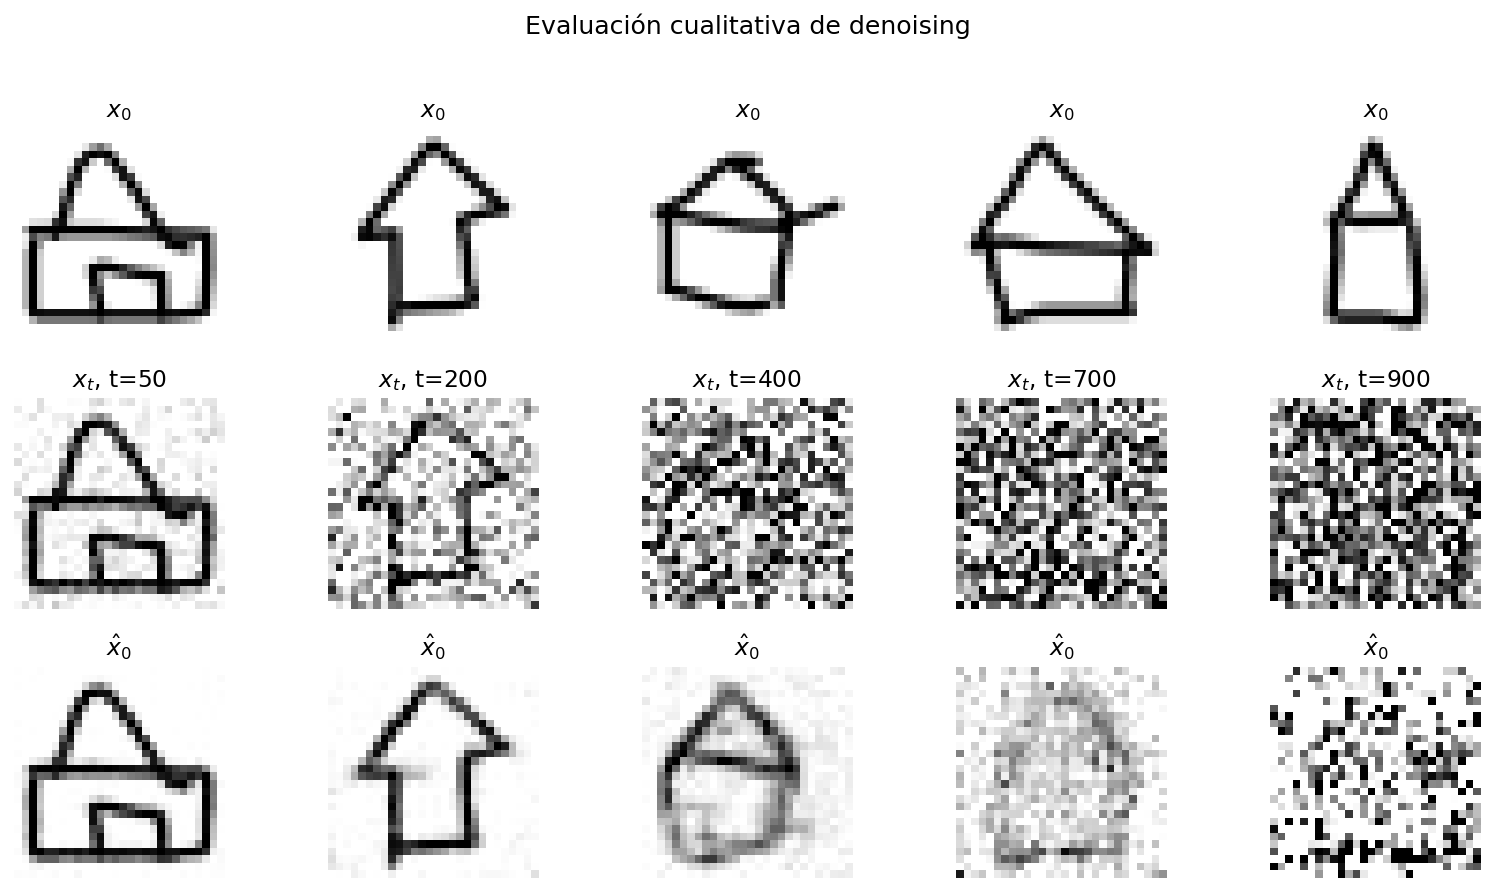

In [8]:
required_names = ["model", "x_train_tensor", "q_sample", "alpha_bars", "DEVICE"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Faltan variables requeridas: " + ", ".join(missing) +
        ". Ejecuta las celdas anteriores en orden antes de evaluar denoising."
    )

def to_image_range(x):
    return torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


def reconstruct_x0_from_epsilon(xt, eps_pred, t_index):
    alpha_bar_t = alpha_bars[t_index].view(-1, 1, 1, 1)
    x0_hat = (xt - torch.sqrt(1.0 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)
    return x0_hat

model.eval()
with torch.no_grad():
    sample_x0 = x_train_tensor[:5].to(DEVICE)
    eval_t = torch.tensor([49, 199, 399, 699, 899], device=DEVICE)
    eps = torch.randn_like(sample_x0)
    xt, eps = q_sample(sample_x0, eval_t, eps)
    eps_pred = model(xt, eval_t)
    x0_hat = reconstruct_x0_from_epsilon(xt, eps_pred, eval_t)

fig, axes = plt.subplots(3, 5, figsize=(11.5, 6.2))
for col in range(5):
    axes[0, col].imshow(to_image_range(sample_x0[col, 0]).cpu(), vmin=0, vmax=1)
    axes[0, col].set_title(r"$x_0$")
    axes[1, col].imshow(to_image_range(xt[col, 0]).cpu(), vmin=0, vmax=1)
    axes[1, col].set_title(rf"$x_t$, t={int(eval_t[col].item()) + 1}")
    axes[2, col].imshow(to_image_range(x0_hat[col, 0]).cpu(), vmin=0, vmax=1)
    axes[2, col].set_title(r"$\hat{x}_0$")
    for row in range(3):
        axes[row, col].axis("off")

axes[0, 0].set_ylabel("limpia", fontsize=11)
axes[1, 0].set_ylabel("ruidosa", fontsize=11)
axes[2, 0].set_ylabel("reconstruida", fontsize=11)
fig.suptitle("Evaluación cualitativa de denoising", y=1.02, fontsize=13)
fig.tight_layout()


## Muestreo reverse básico

Para verificar que el entrenamiento ya puede usarse generativamente, implementamos un muestreo reverse sencillo. Partimos de ruido gaussiano y aplicamos pasos desde $T$ hasta $1$ usando la predicción de ruido del modelo.

Esta sección no pretende ser el análisis definitivo del muestreo. Solo muestra que la función entrenada puede insertarse en un procedimiento generativo. El notebook 05 estudiará con más cuidado número de pasos, semillas, estabilidad y calidad visual.


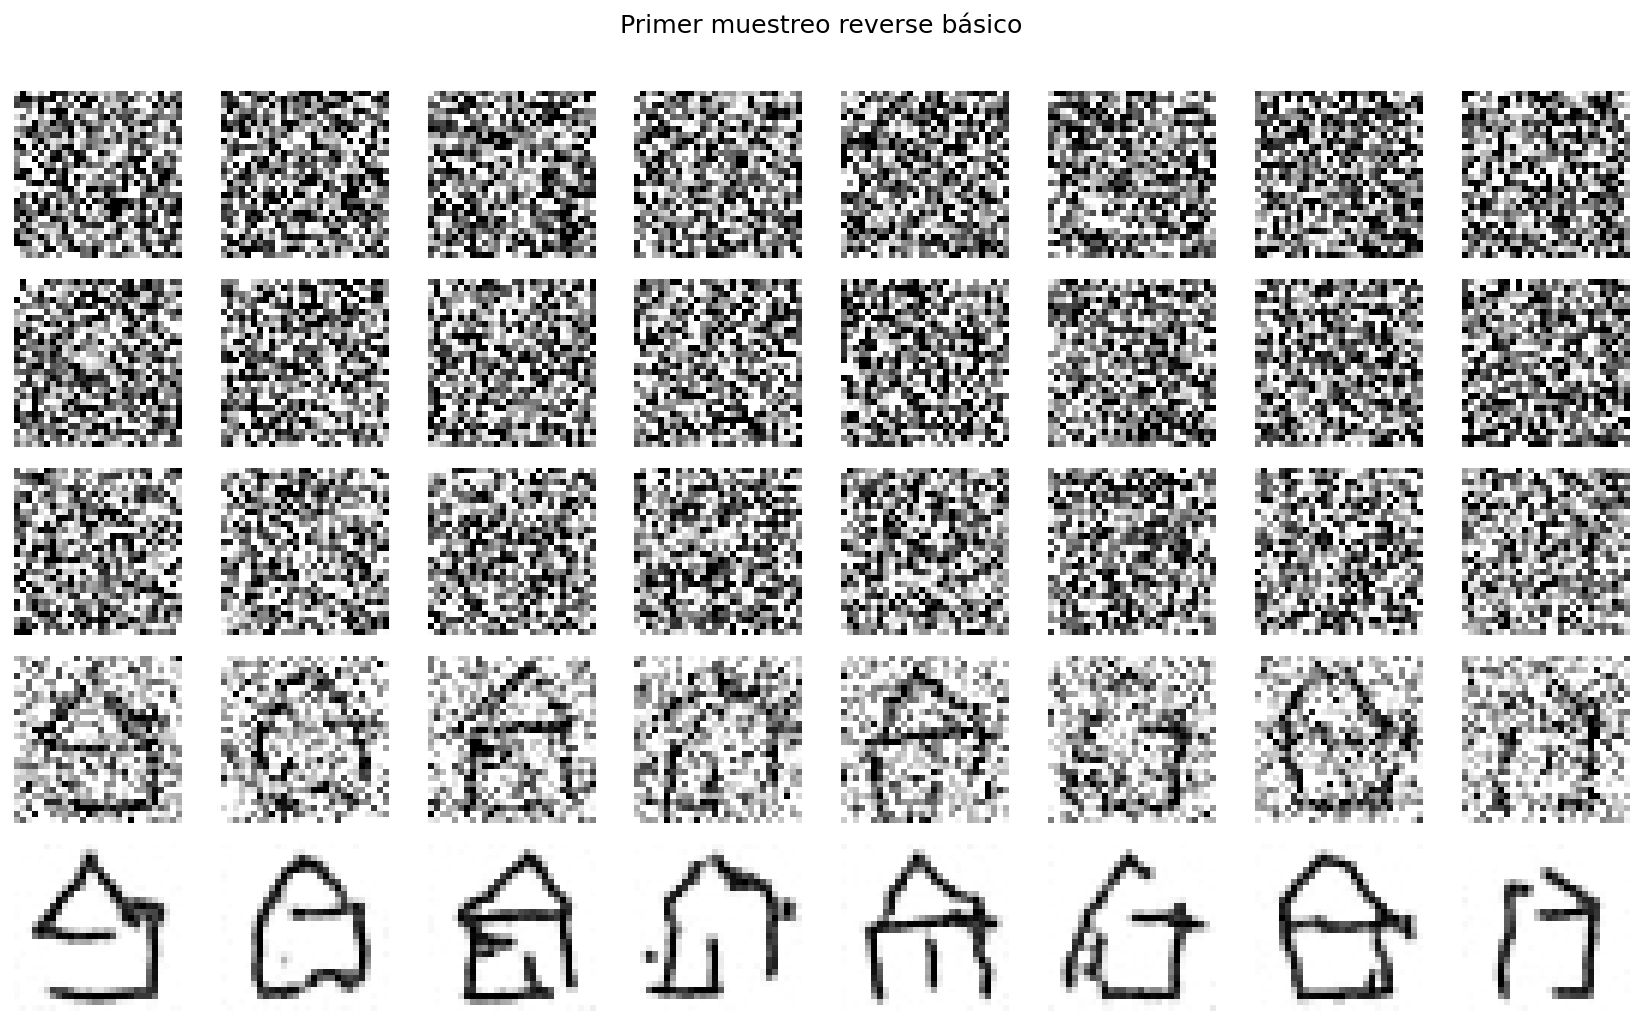

In [9]:
required_names = ["model", "betas", "alphas", "alpha_bars", "DEVICE", "T", "to_image_range"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Faltan variables requeridas: " + ", ".join(missing) +
        ". Ejecuta las celdas anteriores en orden antes de muestrear."
    )

@torch.no_grad()
def p_sample_step(model, x_t, t_index):
    b = x_t.shape[0]
    t_batch = torch.full((b,), t_index, device=x_t.device, dtype=torch.long)
    beta_t = betas[t_index]
    alpha_t = alphas[t_index]
    alpha_bar_t = alpha_bars[t_index]

    eps_pred = model(x_t, t_batch)
    mean = (1.0 / torch.sqrt(alpha_t)) * (
        x_t - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred
    )

    if t_index == 0:
        return mean
    noise = torch.randn_like(x_t)
    posterior_var = beta_t * (1.0 - alpha_bars[t_index - 1]) / (1.0 - alpha_bar_t)
    return mean + torch.sqrt(torch.clamp(posterior_var, min=1e-20)) * noise


@torch.no_grad()
def sample_reverse(model, n_samples=16, save_steps=(999, 749, 499, 249, 0)):
    model.eval()
    x = torch.randn(n_samples, 1, 28, 28, device=DEVICE)
    snapshots = {}
    for t_index in reversed(range(T)):
        x = p_sample_step(model, x, t_index)
        if t_index in save_steps:
            snapshots[t_index] = x.detach().cpu().clone()
    return snapshots

snapshots = sample_reverse(model, n_samples=16)
ordered_steps = sorted(snapshots.keys(), reverse=True)

fig, axes = plt.subplots(len(ordered_steps), 8, figsize=(12, 7.2))
for row, t_index in enumerate(ordered_steps):
    images = snapshots[t_index]
    for col in range(8):
        axes[row, col].imshow(to_image_range(images[col, 0]).numpy(), vmin=0, vmax=1)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(f"t={t_index + 1}", fontsize=10)
fig.suptitle("Primer muestreo reverse básico", y=1.01, fontsize=13)
fig.tight_layout()


## Muestras finales

Mostramos algunas muestras al final de la cadena. El modelo sigue siendo pequeño y no condicional, pero ya debe producir dibujos reconocibles a partir de ruido gaussiano inicial. Esta es la primera evidencia computacional de que la predicción de ruido puede convertirse en un procedimiento generativo.

La calidad visual no debe interpretarse como el límite de los modelos de difusión. Debe interpretarse como una prueba controlada: con imágenes de baja resolución, una sola clase y una red compacta, el mecanismo ya aprende una distribución visual.


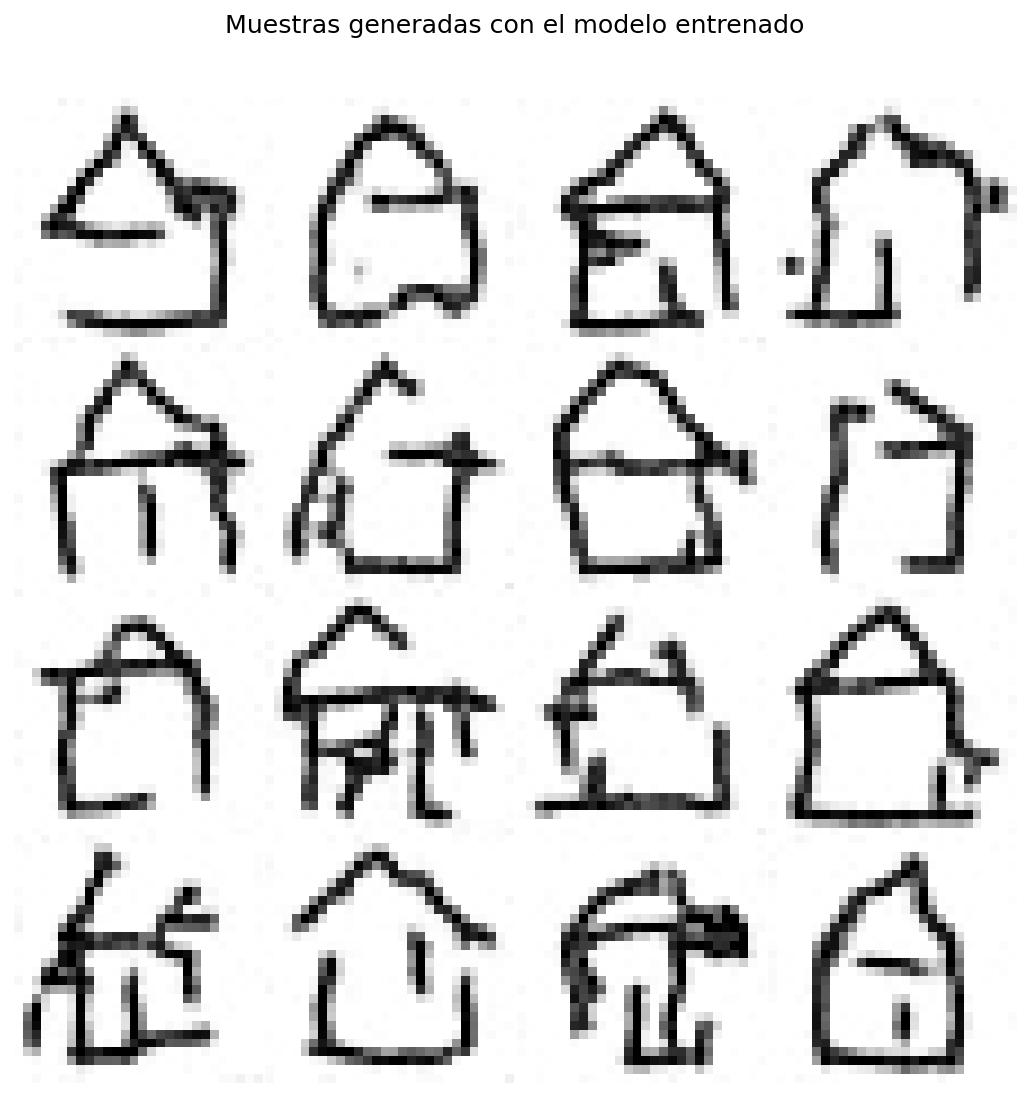

In [10]:
required_names = ["snapshots", "to_image_range"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Faltan variables requeridas: " + ", ".join(missing) +
        ". Ejecuta primero la sección 'Muestreo reverse básico'."
    )

final_samples = snapshots[0]
fig, axes = plt.subplots(4, 4, figsize=(7.2, 7.8))
for ax, image in zip(axes.ravel(), final_samples):
    ax.imshow(to_image_range(image[0]).numpy(), vmin=0, vmax=1, interpolation="nearest")
    ax.axis("off")
fig.suptitle("Muestras generadas con el modelo entrenado", y=0.985, fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94], pad=0.15)


## Síntesis

**Resultado conceptual.** La función abstracta $\epsilon_\theta(x_t,t)$ ya fue reemplazada por una red neuronal concreta. La arquitectura contiene los elementos esenciales: convoluciones para procesar la imagen ruidosa, condicionamiento temporal para distinguir niveles de ruido y una estructura multiescala para coordinar información local y global.

El entrenamiento optimizó la pérdida

$$
\left\|\epsilon-\epsilon_\theta(x_t,t)\right\|_2^2,
$$

y la evaluación mostró dos usos de la predicción de ruido: reconstruir una estimación $\hat{x}_0$ y ejecutar un primer muestreo reverse desde ruido gaussiano.

La lección principal no es que esta sea la arquitectura final. La lección es que la formulación del notebook anterior se convirtió en un modelo entrenable y funcional.


## Preguntas de discusión

1. ¿Por qué el dataset del `DataLoader` solo contiene $x_0$ y no almacena todos los pares $(x_t,\epsilon)$?
2. ¿Qué papel cumple el embedding temporal dentro de la red?
3. ¿Por qué una arquitectura multiescala ayuda más que una CNN plana cuando queremos muestrear imágenes completas?
4. ¿Qué diferencia hay entre evaluar denoising y muestrear desde ruido?
5. ¿Qué limitaciones observas en las muestras generadas por este modelo pequeño?
6. ¿Qué partes del muestreo reverse deberían estudiarse con más cuidado en el siguiente notebook?


## Continuidad

El siguiente notebook estudiará el muestreo iterativo con más detalle. Allí analizaremos cómo cambian las muestras con distintas semillas, cuántos pasos de muestreo usar, qué limita la calidad visual y cómo interpretar cualitativamente los resultados generados.
